# 07 - IVF (Inverted File Index)

---

In the previous notebook, we learned Clustering using K-Means.

Now we'll answer an important question:

How can clustering make vector search faster?

The answer is **IVF (Inverted File Index)**.

IVF is one of the most popular indexing methods used in modern vector search systems.

##  History

Flat Index compares every vector.

As datasets grew,

this became expensive.

Researchers observed:

Similar vectors naturally form groups.

Instead of searching the whole database,

why not search only inside the most relevant group?

This idea became the **Inverted File Index (IVF)**.

## Think Like a Researcher

Imagine a supermarket.

Products are grouped into sections.

🥛 Dairy

🍎 Fruits

🥤 Drinks

🥖 Bakery

If you need milk,

you don't walk through every aisle.

You go directly to the Dairy section.

IVF works the same way.

It first finds the correct cluster,

then searches only inside that cluster.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

cluster1 = np.random.randn(40,2)+[2,2]
cluster2 = np.random.randn(40,2)+[8,2]
cluster3 = np.random.randn(40,2)+[5,8]

vectors=np.vstack([
    cluster1,
    cluster2,
    cluster3
])

In [2]:
from sklearn.cluster import KMeans

kmeans=KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels=kmeans.fit_predict(vectors)

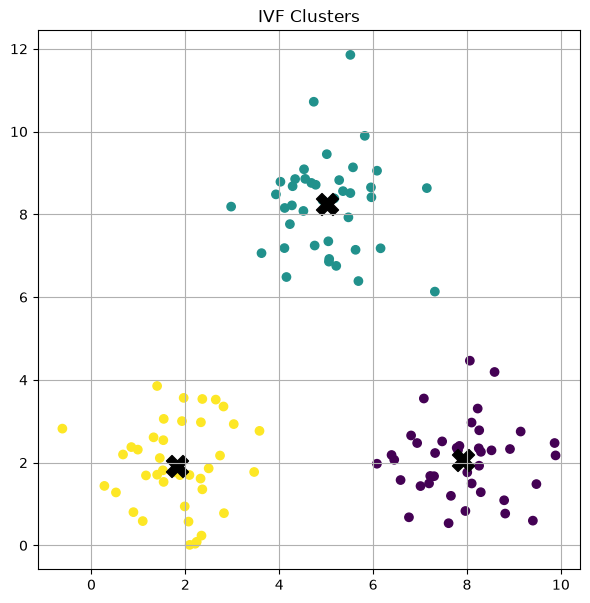

In [3]:
plt.figure(figsize=(7,7))

plt.scatter(
    vectors[:,0],
    vectors[:,1],
    c=labels
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker="X",
    s=250,
    color="black"
)

plt.title("IVF Clusters")

plt.grid()

plt.show()

In [4]:
query=np.array([[5.3,7.6]])

cluster=kmeans.predict(query)

cluster

array([1], dtype=int32)

In [5]:
cluster_id=cluster[0]

candidate_vectors=vectors[
    labels==cluster_id
]

candidate_vectors.shape

(40, 2)

In [6]:
print("All vectors :",len(vectors))

print("Candidate vectors :",len(candidate_vectors))

All vectors : 120
Candidate vectors : 40


In [7]:
def euclidean(a,b):
    return np.sqrt(np.sum((a-b)**2))

results=[]

for vector in candidate_vectors:

    d=euclidean(
        query[0],
        vector
    )

    results.append(d)

sorted(results)[:5]

[np.float64(0.357821776259213),
 np.float64(0.370205611736463),
 np.float64(0.5612951565698746),
 np.float64(0.6500595903849961),
 np.float64(0.717566647363211)]

## IVF Pipeline

```
Documents

↓

Embeddings

↓

KMeans

↓

Clusters

↓

Query

↓

Nearest Cluster

↓

Search Inside Cluster

↓

Top K
```

## What is nlist?

In IVF,

the number of clusters is called **nlist**.

Example:

nlist = 100

↓

100 clusters

More clusters

↓

Smaller search space

But choosing too many clusters may reduce recall.

## What is nprobe?

Sometimes the nearest document is in a neighboring cluster.

Searching only one cluster may miss it.

nprobe tells IVF how many clusters to search.

nprobe = 1

↓

Search only one cluster.

nprobe = 5

↓

Search five nearby clusters.

Higher nprobe usually improves recall but increases search time.

## Advantages

✅ Much faster than Flat Index

✅ Scales well

✅ Works well on large datasets

✅ Foundation for many production systems

## Limitations

❌ May miss the true nearest neighbor

❌ Depends on clustering quality

❌ Requires tuning nlist and nprobe

## Summary

Today I learned:

- How IVF works
- Why clustering improves search
- nlist
- nprobe
- IVF search pipeline
- Advantages and limitations

##  Think Like a Researcher

IVF is much faster than Flat Index.

But another problem appears.

Modern embedding models produce vectors with:

- 384 dimensions
- 768 dimensions
- 1536 dimensions

Does every indexing algorithm work well in such high-dimensional spaces?

The answer is no.

This challenge is called the **Curse of Dimensionality**.